In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier)
from sklearn.metrics import (mean_absolute_error,mean_squared_error, r2_score, accuracy_score,classification_report, recall_score, make_scorer)
from sklearn.inspection import permutation_importance
from skopt import BayesSearchCV
from skopt.space import Integer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, ConfusionMatrixDisplay
import joblib

In [2]:
cwd = Path.cwd().resolve()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd

DATA_PATH = BASE_DIR / "data" / "processed" / "modeling_dataset.csv"

OUTPUT_DIR = BASE_DIR / "outputs" / "RF_modeling"
FIGURE_DIR = BASE_DIR / "outputs" / "final_figures" / "RF_modeling"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data path:", DATA_PATH)

# Loading modelling dataset

fleet_df = pd.read_csv(DATA_PATH)
fleet_df["date"] = pd.to_datetime(fleet_df["date"])
fleet_df = fleet_df.sort_values(["blower_id", "date"]).copy()

print("Dataset loaded successfully.")
print("Shape:", fleet_df.shape)
print("Date range:", fleet_df["date"].min(), "to", fleet_df["date"].max())
print("Number of blowers:", fleet_df["blower_id"].nunique())

fleet_df.head()

Base directory: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis
Data path: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\modeling_dataset.csv
Dataset loaded successfully.
Shape: (4380, 34)
Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
Number of blowers: 12


,date,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph,blower_id,site_id,operational_class,max_op_ambient_temp_c,...,health_score,maintenance_event_triggered,failure_event,RUL_days,maintenance_due_90d,previous_maintenance_event,maintenance_cycle,days_since_maintenance,cycle_start_cumulative_hours,hours_since_maintenance
0,2025-01-01,35.777778,23.555556,29.333333,63.9,17.2,ZG150_B001,Site_01,High Duty,48.9,...,99.262303,0,0,165.103543,0,0,0,0,22.457076,0.000000
1,2025-01-02,31.777778,20.722222,26.055556,79.5,15.0,ZG150_B001,Site_01,High Duty,48.9,...,98.703011,0,0,164.173270,0,0,0,1,22.457076,20.440024
2,2025-01-03,31.611111,22.222222,26.611111,78.3,13.9,ZG150_B001,Site_01,High Duty,48.9,...,98.176655,0,0,163.297779,0,0,0,2,22.457076,43.565701
3,2025-01-04,32.722222,23.722222,28.000000,71.4,12.9,ZG150_B001,Site_01,High Duty,48.9,...,97.606606,0,0,162.349612,0,0,0,3,22.457076,66.976548
4,2025-01-05,34.111111,22.500000,29.388889,66.3,19.8,ZG150_B001,Site_01,High Duty,48.9,...,96.939732,0,0,161.240397,0,0,0,4,22.457076,86.976548


In [3]:
# Checking required columns

required_columns = [
    "date",
    "blower_id",
    "site_id",
    "operational_class",
    "daily_op_hours",
    "cumulative_op_hours",
    "days_since_maintenance",
    "hours_since_maintenance",
    "daily_load_percent",
    "humidity",
    "wind_gust_kph",
    "dust_index",
    "pressure_diff_psi",
    "casing_temperature_c",
    "vibration_mm_s",
    "RUL_days",
    "maintenance_event",
    "maintenance_due_90d",
    "degradation_index",
    "health_score"
]

missing_columns = [
    col for col in required_columns if col not in fleet_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required modelling columns are available.")

All required modelling columns are available.


RANDOM FOREST REGRESSOR

In [4]:
# Defining target and three feature set options
target = "RUL_days"

feature_sets = {
    "Option_A_Full_Model": [
        "daily_op_hours",
        "cumulative_op_hours",
        "days_since_maintenance",
        "hours_since_maintenance",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
        "operational_class",
    ],

    "Option_B_Reduced_With_Duty_Class": [
        "daily_op_hours",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
        "operational_class",
    ],

    "Option_C_Condition_Only": [
        "daily_op_hours",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
    ]
}

for option_name, features in feature_sets.items():
    print("\n" + "=" * 70)
    print(option_name)
    print("=" * 70)
    for feature in features:
        print("-", feature)


Option_A_Full_Model
- daily_op_hours
- cumulative_op_hours
- days_since_maintenance
- hours_since_maintenance
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s
- operational_class

Option_B_Reduced_With_Duty_Class
- daily_op_hours
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s
- operational_class

Option_C_Condition_Only
- daily_op_hours
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s


In [5]:
#Defining train-test split

split_date = pd.Timestamp("2025-10-01")

print("Split date:", split_date)

Split date: 2025-10-01 00:00:00


In [6]:
#Functioning to train and evaluate one Random Forest model option

def train_random_forest_option(option_name, model_features, fleet_df, target, split_date):
    print("\n" + "=" * 80)
    print(f"Training {option_name}")
    print("=" * 80)

    model_df = fleet_df.dropna(subset=model_features + [target]).copy()

    X = model_df[model_features].copy()
    y = model_df[target].copy()

    if "operational_class" in X.columns:
        X = pd.get_dummies(
            X,
            columns=["operational_class"],
            drop_first=False
        )

    train_mask = model_df["date"] < split_date
    test_mask = model_df["date"] >= split_date

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    print("Training records:", X_train.shape[0])
    print("Testing records:", X_test.shape[0])
    print("Number of features:", X_train.shape[1])

    rf_regressor = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nResults")
    print("-" * 40)
    print(f"MAE:  {mae:.2f} days")
    print(f"RMSE: {rmse:.2f} days")
    print(f"R²:   {r2:.4f}")

    metrics_df = pd.DataFrame([{
        "option": option_name,
        "model": "Random Forest Regressor",
        "target": target,
        "number_of_features": X_train.shape[1],
        "train_start": model_df.loc[train_mask, "date"].min(),
        "train_end": model_df.loc[train_mask, "date"].max(),
        "test_start": model_df.loc[test_mask, "date"].min(),
        "test_end": model_df.loc[test_mask, "date"].max(),
        "mae_days": mae,
        "rmse_days": rmse,
        "r2_score": r2
    }])

    test_predictions = model_df.loc[test_mask, [
        "date",
        "blower_id",
        "site_id",
        "operational_class",
        "RUL_days",
        "degradation_index",
        "health_score",
        "maintenance_event",
        "maintenance_due_90d"
    ]].copy()

    pred_col = f"{option_name}_rf_predicted_RUL_days"
    error_col = f"{option_name}_rf_absolute_error_days"
    residual_col = f"{option_name}_rf_residual_days"

    test_predictions[pred_col] = y_pred

    test_predictions[error_col] = (
        test_predictions["RUL_days"] - test_predictions[pred_col]
    ).abs()

    test_predictions[residual_col] = (
        test_predictions["RUL_days"] - test_predictions[pred_col]
    )

    test_predictions[f"{option_name}_rf_maintenance_due_90d_pred"] = (
        test_predictions[pred_col] <= 90
    ).astype(int)

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_regressor.feature_importances_
    }).sort_values(by="importance", ascending=False)

    full_predictions = rf_regressor.predict(X)
    full_predictions = np.clip(full_predictions, 0, None)

    full_prediction_df = model_df.copy()
    full_prediction_df[pred_col] = full_predictions

    full_prediction_df[f"{option_name}_rf_maintenance_due_90d_pred"] = (
        full_prediction_df[pred_col] <= 90
    ).astype(int)

    full_prediction_df["data_split"] = np.where(
        full_prediction_df["date"] < split_date,
        "train",
        "test"
    )

    return {
        "option_name": option_name,
        "model": rf_regressor,
        "metrics": metrics_df,
        "test_predictions": test_predictions,
        "feature_importance": importance_df,
        "full_predictions": full_prediction_df,
        "pred_col": pred_col,
        "residual_col": residual_col,
        "X_train_columns": X_train.columns.tolist()
    }

In [7]:
# Training all three Random Forest options

rf_results = {}

for option_name, features in feature_sets.items():
    rf_results[option_name] = train_random_forest_option(
        option_name=option_name,
        model_features=features,
        fleet_df=fleet_df,
        target=target,
        split_date=split_date
    )


Training Option_A_Full_Model
Training records: 3276
Testing records: 1104
Number of features: 14

Results
----------------------------------------
MAE:  12.03 days
RMSE: 16.82 days
R²:   0.6883

Training Option_B_Reduced_With_Duty_Class
Training records: 3276
Testing records: 1104
Number of features: 11

Results
----------------------------------------
MAE:  27.52 days
RMSE: 34.02 days
R²:   -0.2744

Training Option_C_Condition_Only
Training records: 3276
Testing records: 1104
Number of features: 8

Results
----------------------------------------
MAE:  27.52 days
RMSE: 34.02 days
R²:   -0.2744


In [8]:
#Combining and saving metrics comparison

metrics_comparison = pd.concat(
    [result["metrics"] for result in rf_results.values()],
    ignore_index=True
).sort_values(by="rmse_days")

metrics_comparison_path = OUTPUT_DIR / "random_forest_three_option_metrics_comparison.csv"

metrics_comparison.to_csv(
    metrics_comparison_path,
    index=False
)

metrics_comparison

,option,model,target,number_of_features,train_start,train_end,test_start,test_end,mae_days,rmse_days,r2_score
0,Option_A_Full_Model,Random Forest Regressor,RUL_days,14,2025-01-01,2025-09-30,2025-10-01,2025-12-31,12.027344,16.824049,0.688255
2,Option_C_Condition_Only,Random Forest Regressor,RUL_days,8,2025-01-01,2025-09-30,2025-10-01,2025-12-31,27.517705,34.015926,-0.274391
1,Option_B_Reduced_With_Duty_Class,Random Forest Regressor,RUL_days,11,2025-01-01,2025-09-30,2025-10-01,2025-12-31,27.519249,34.015977,-0.274395


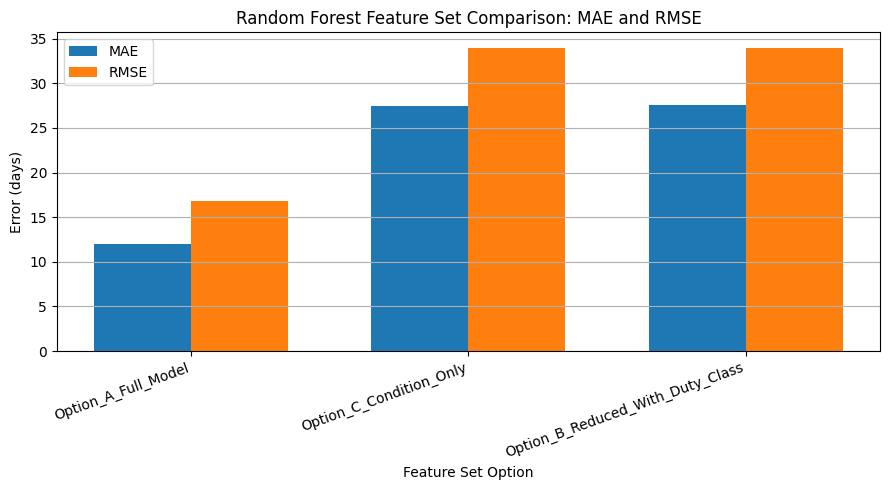

In [9]:
#Plotting metrics comparison: MAE and RMSE

plot_metrics = metrics_comparison.copy()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_metrics))
width = 0.35

ax.bar(
    x - width / 2,
    plot_metrics["mae_days"],
    width,
    label="MAE"
)

ax.bar(
    x + width / 2,
    plot_metrics["rmse_days"],
    width,
    label="RMSE"
)

ax.set_title("Random Forest Feature Set Comparison: MAE and RMSE")
ax.set_xlabel("Feature Set Option")
ax.set_ylabel("Error (days)")
ax.set_xticks(x)
ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")
ax.legend()
ax.grid(True, axis="y")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "random_forest_three_option_mae_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_10380\86943139.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")


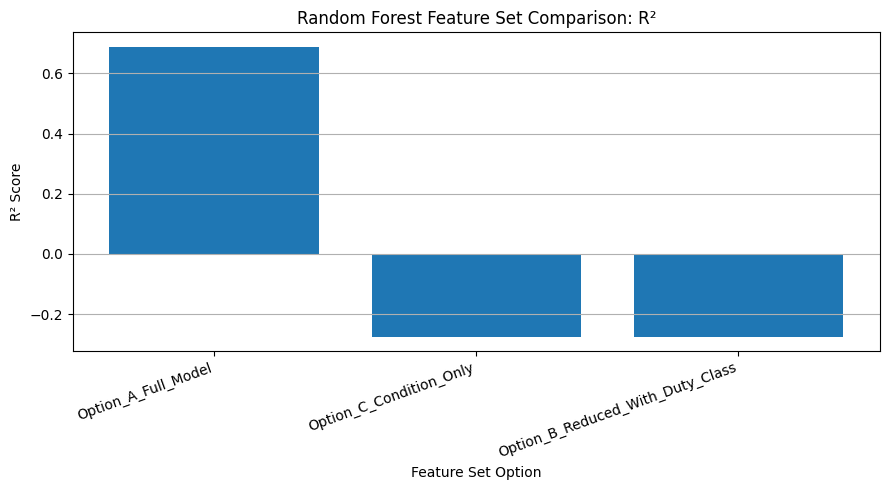

In [10]:
#Plotting metrics comparison: R²

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_metrics["option"],
    plot_metrics["r2_score"]
)

ax.set_title("Random Forest Feature Set Comparison: R²")
ax.set_xlabel("Feature Set Option")
ax.set_ylabel("R² Score")
ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")
ax.grid(True, axis="y")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "random_forest_three_option_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# Saving outputs and plots for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    model_path = OUTPUT_DIR / f"{safe_name}_random_forest_rul_model.joblib"
    joblib.dump(result["model"], model_path)

    test_predictions_path = OUTPUT_DIR / f"{safe_name}_test_predictions.csv"
    result["test_predictions"].to_csv(test_predictions_path, index=False)

    importance_path = OUTPUT_DIR / f"{safe_name}_feature_importance.csv"
    result["feature_importance"].to_csv(importance_path, index=False)

    full_predictions_path = PROCESSED_DIR / f"{safe_name}_rf_modeling_dataset_with_predictions.csv"
    result["full_predictions"].to_csv(full_predictions_path, index=False)

    test_policy_path = PROCESSED_DIR / f"{safe_name}_rf_test_policy_predictions.csv"
    result["test_predictions"].to_csv(test_policy_path, index=False)

    print(f"\nSaved outputs for {option_name}")
    print("- Model:", model_path)
    print("- Test predictions:", test_predictions_path)
    print("- Feature importance:", importance_path)
    print("- Full predictions:", full_predictions_path)
    print("- Test-only policy predictions:", test_policy_path)


Saved outputs for Option_A_Full_Model
- Model: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\option_a_full_model_random_forest_rul_model.joblib
- Test predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\option_a_full_model_test_predictions.csv
- Feature importance: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\option_a_full_model_feature_importance.csv
- Full predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\option_a_full_model_rf_modeling_dataset_with_predictions.csv
- Test-only policy predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\option_a_full_model_rf_test_policy_predictions.csv

Saved outputs for Option_B_Reduced_With_Duty_Class
- Model: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\option_b_reduced_with_duty

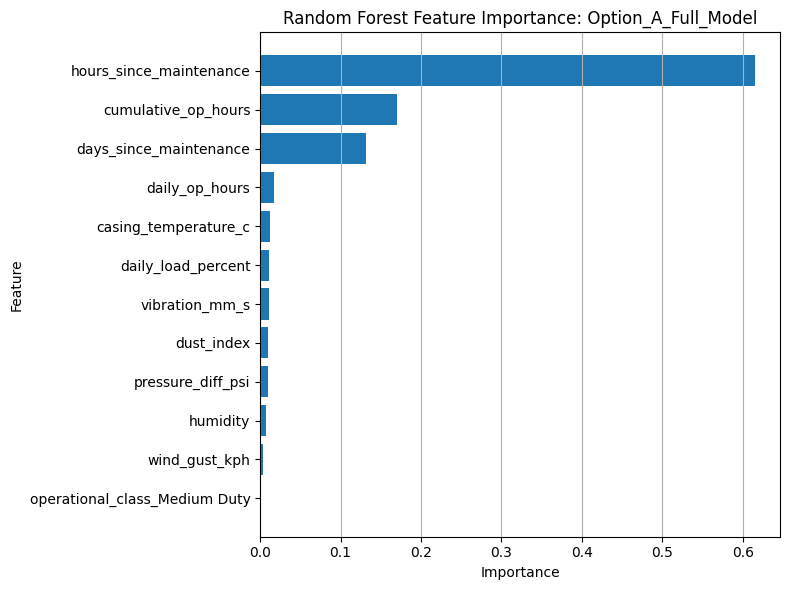

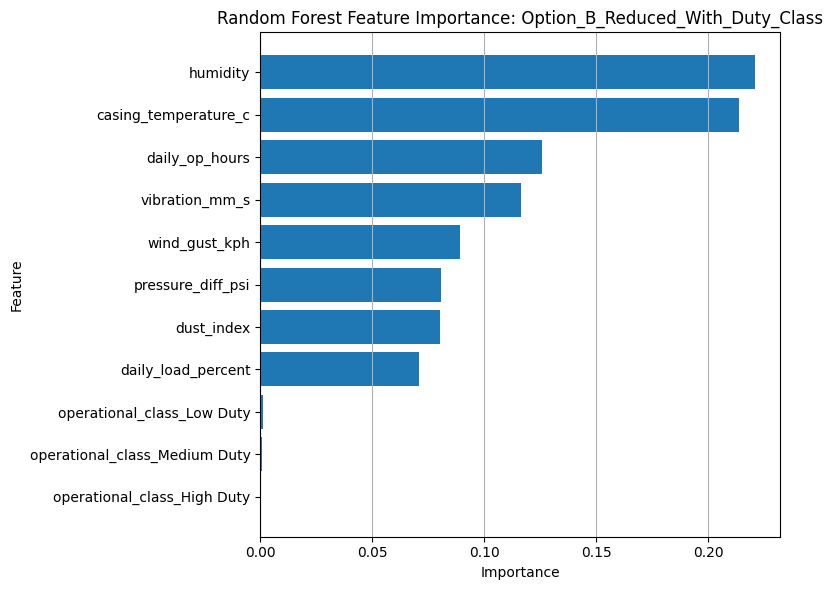

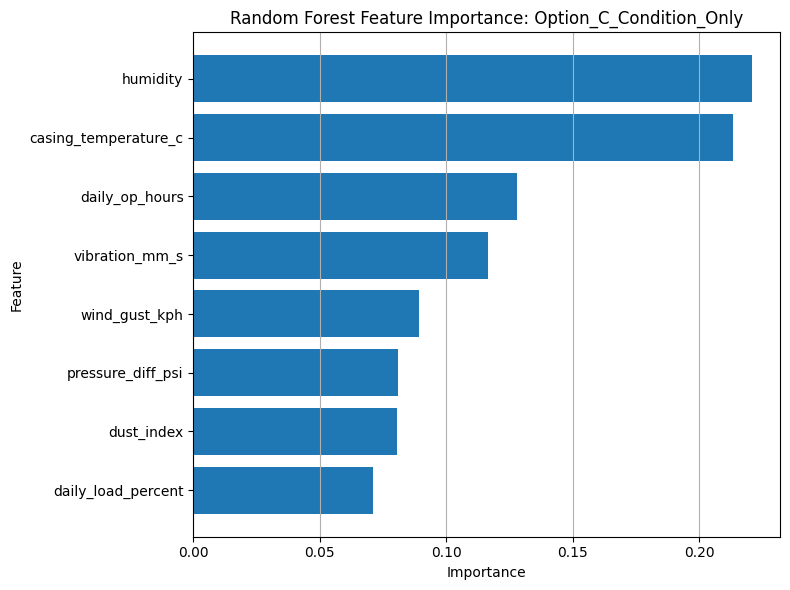

In [12]:
# Plotting feature importance for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    importance_df = result["feature_importance"]

    top_n = min(12, len(importance_df))

    plot_df = importance_df.sort_values(
        by="importance",
        ascending=True
    ).tail(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    ax.set_title(f"Random Forest Feature Importance: {option_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.grid(True, axis="x")

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

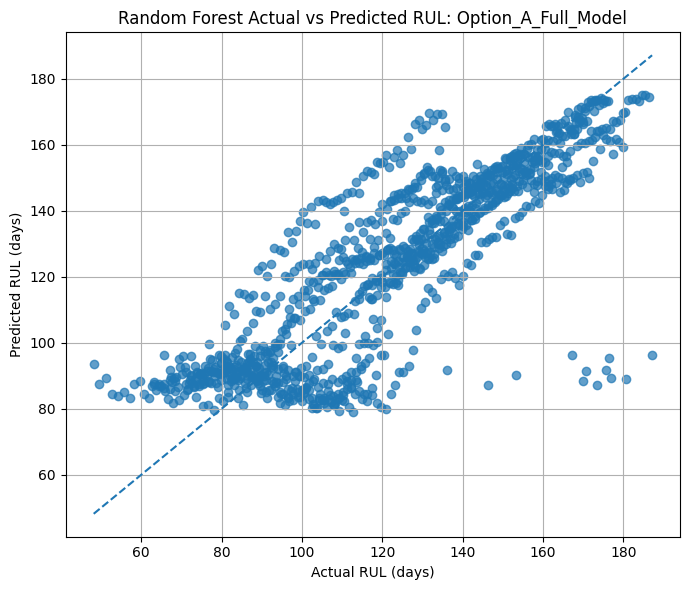

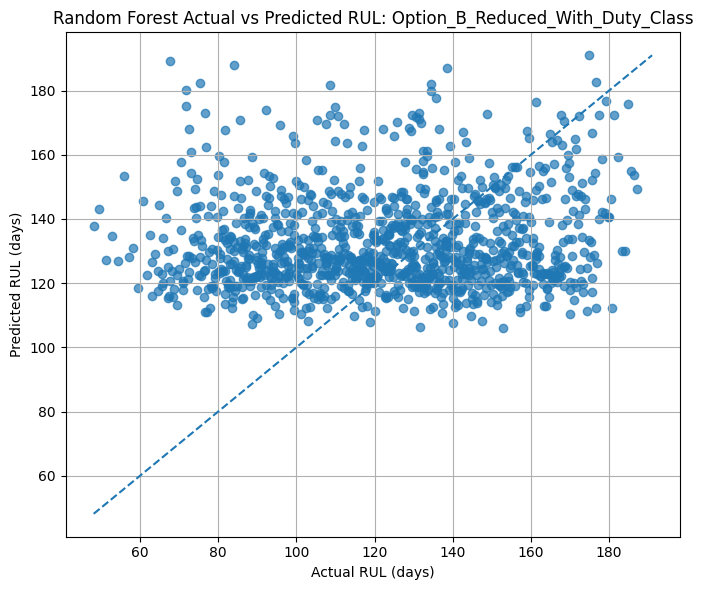

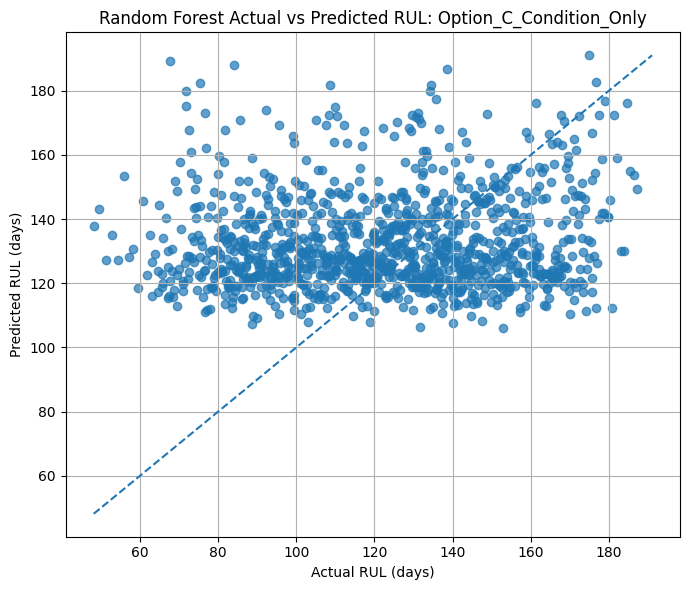

In [13]:
# Plotting actual vs predicted RUL scatter for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(
        test_predictions["RUL_days"],
        test_predictions[pred_col],
        alpha=0.7
    )

    min_value = min(
        test_predictions["RUL_days"].min(),
        test_predictions[pred_col].min()
    )

    max_value = max(
        test_predictions["RUL_days"].max(),
        test_predictions[pred_col].max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_title(f"Random Forest Actual vs Predicted RUL: {option_name}")
    ax.set_xlabel("Actual RUL (days)")
    ax.set_ylabel("Predicted RUL (days)")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

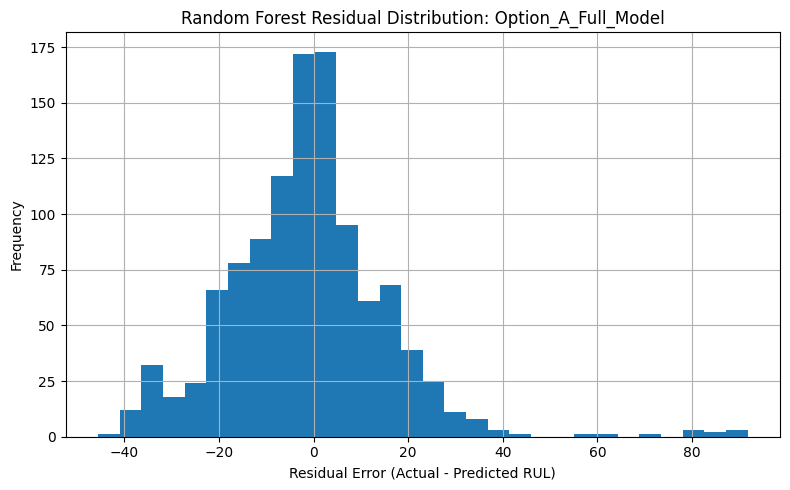

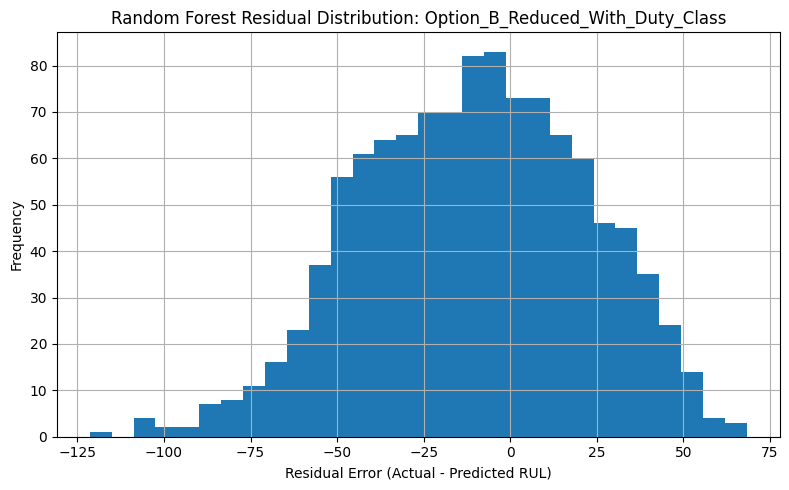

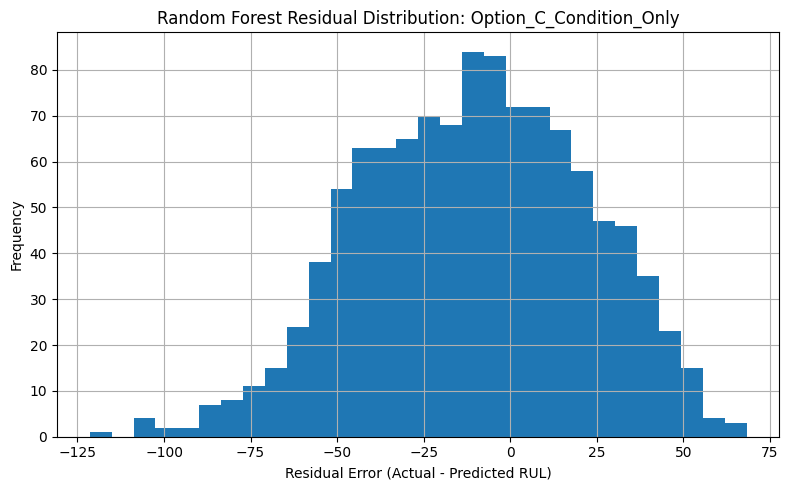

In [14]:
# Plotting residual distribution for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    residual_col = result["residual_col"]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        test_predictions[residual_col],
        bins=30
    )

    ax.set_title(f"Random Forest Residual Distribution: {option_name}")
    ax.set_xlabel("Residual Error (Actual - Predicted RUL)")
    ax.set_ylabel("Frequency")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_residual_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

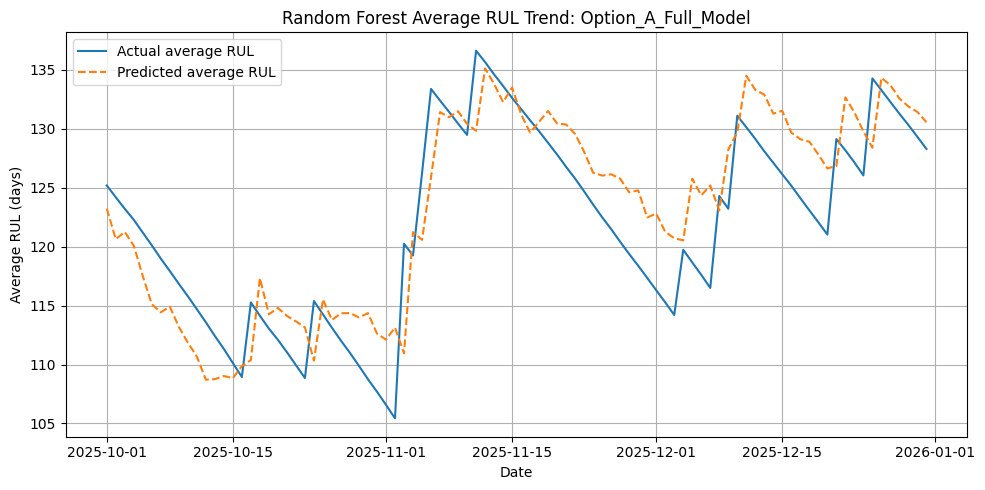

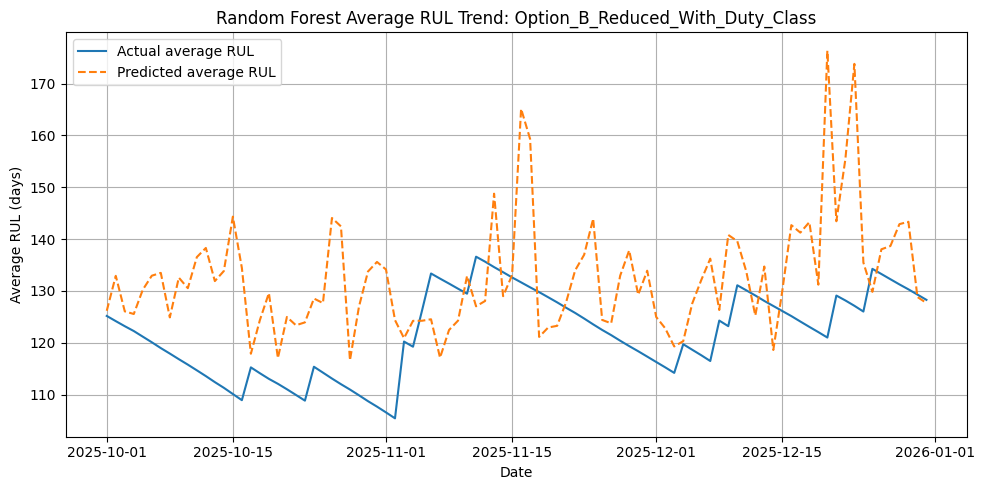

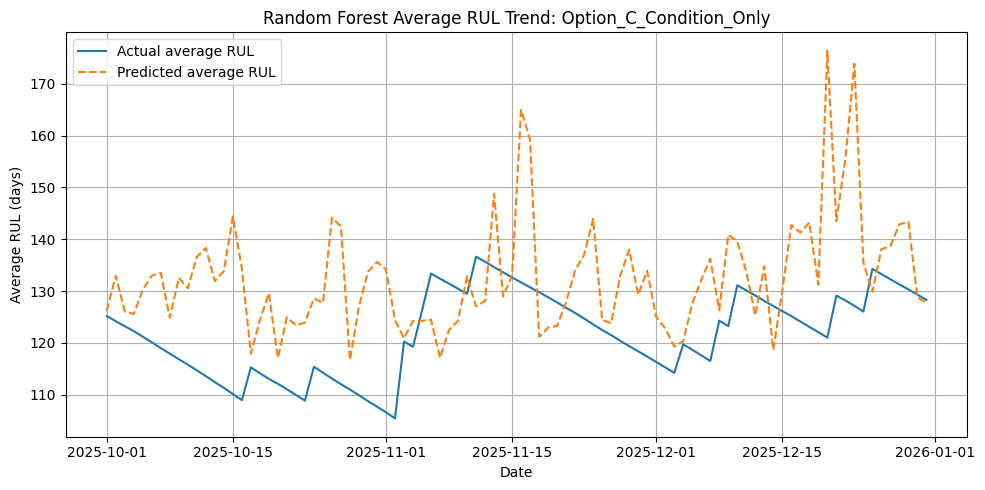

In [15]:
#Fleet-average actual vs predicted RUL trend for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    fleet_rul_trend = (
        test_predictions
        .groupby("date")[["RUL_days", pred_col]]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        fleet_rul_trend["date"],
        fleet_rul_trend["RUL_days"],
        label="Actual average RUL"
    )

    ax.plot(
        fleet_rul_trend["date"],
        fleet_rul_trend[pred_col],
        linestyle="--",
        label="Predicted average RUL"
    )

    ax.set_title(f"Random Forest Average RUL Trend: {option_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average RUL (days)")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_average_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

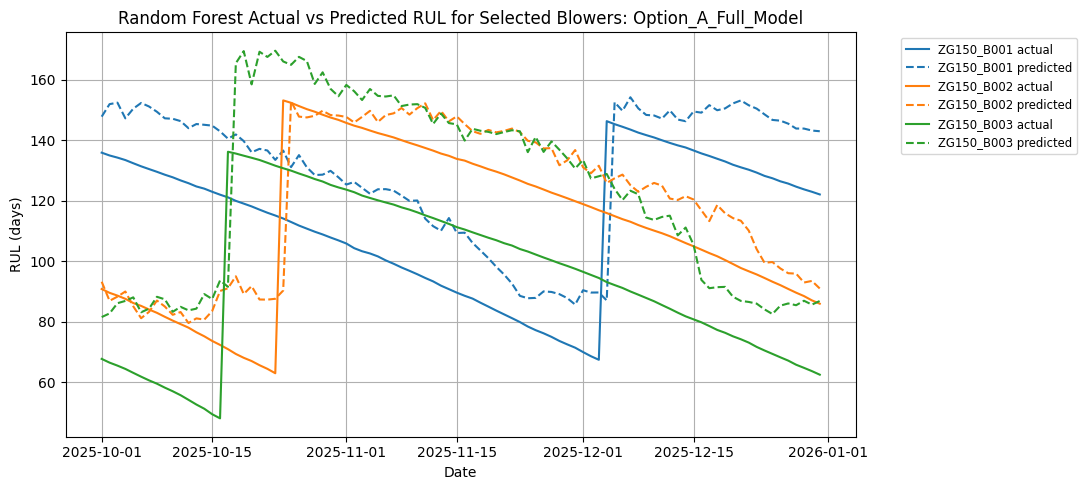

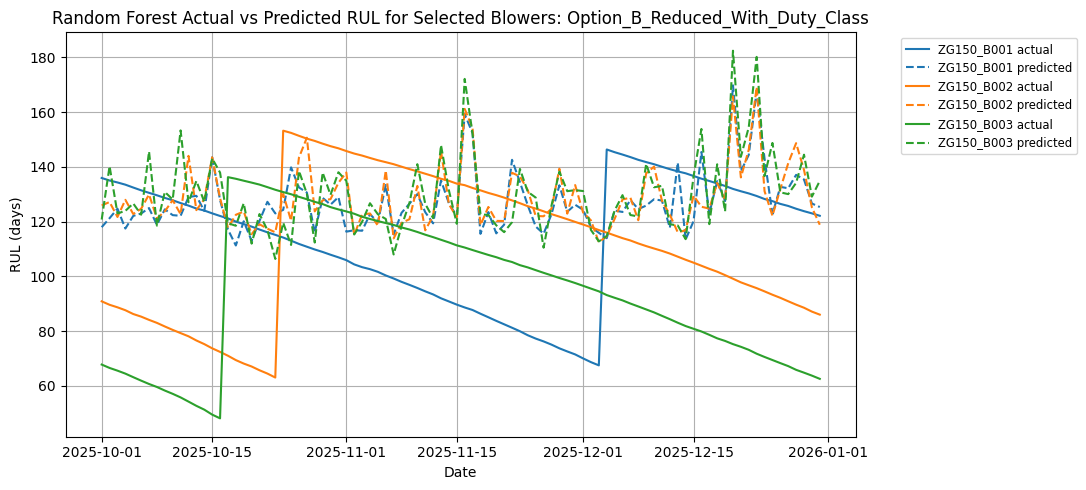

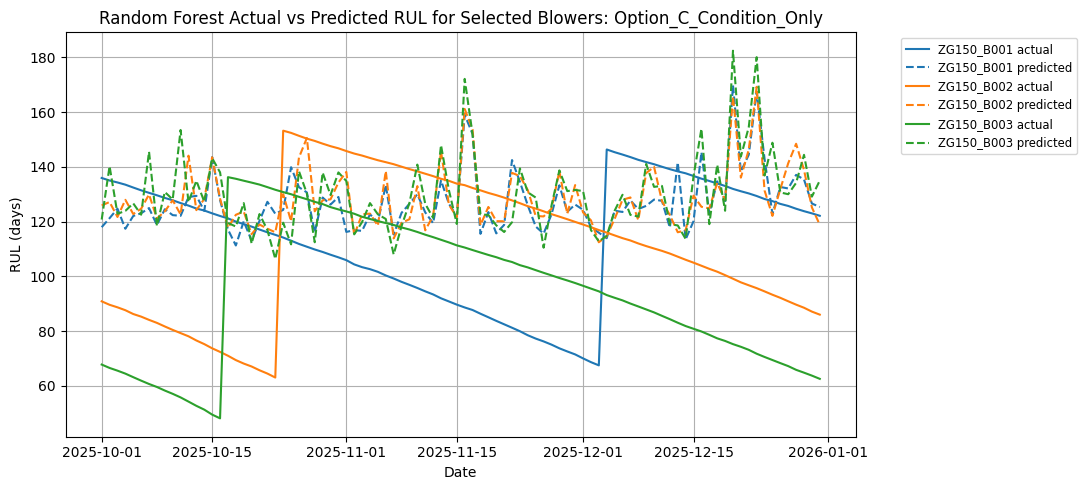

In [16]:
#Selected blower actual vs predicted RUL trend for each option

for option_name, result in rf_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    selected_blowers = test_predictions["blower_id"].unique()[:3]

    fig, ax = plt.subplots(figsize=(11, 5))

    colour_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, blower in enumerate(selected_blowers):
        subset = (
            test_predictions[test_predictions["blower_id"] == blower]
            .sort_values("date")
        )

        colour = colour_cycle[i % len(colour_cycle)]

        ax.plot(
            subset["date"],
            subset["RUL_days"],
            color=colour,
            linestyle="-",
            label=f"{blower} actual"
        )

        ax.plot(
            subset["date"],
            subset[pred_col],
            color=colour,
            linestyle="--",
            label=f"{blower} predicted"
        )

    ax.set_title(f"Random Forest Actual vs Predicted RUL for Selected Blowers: {option_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("RUL (days)")
    ax.legend(fontsize="small", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_selected_blowers_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [17]:
#Creating combined test-only policy prediction dataset for RF options

combined_policy_df = None

for option_name, result in rf_results.items():

    test_df = result["test_predictions"].copy()

    keep_cols = [
        "date",
        "blower_id",
        "site_id",
        "operational_class",
        "RUL_days",
        "degradation_index",
        "health_score",
        "maintenance_event",
        "maintenance_due_90d",
        result["pred_col"],
        f"{option_name}_rf_maintenance_due_90d_pred"
    ]

    test_df = test_df[keep_cols].copy()

    if combined_policy_df is None:
        combined_policy_df = test_df
    else:
        merge_cols = [
            "date",
            "blower_id",
            "site_id",
            "operational_class",
            "RUL_days",
            "degradation_index",
            "health_score",
            "maintenance_event",
            "maintenance_due_90d"
        ]

        combined_policy_df = combined_policy_df.merge(
            test_df,
            on=merge_cols,
            how="left"
        )

combined_policy_path = PROCESSED_DIR / "random_forest_three_option_test_policy_predictions.csv"

combined_policy_df.to_csv(
    combined_policy_path,
    index=False
)

print("Combined policy-ready RF test prediction dataset saved to:")
print(combined_policy_path)

combined_policy_df.head()

Combined policy-ready RF test prediction dataset saved to:
C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\random_forest_three_option_test_policy_predictions.csv


,date,blower_id,site_id,operational_class,RUL_days,degradation_index,health_score,maintenance_event,maintenance_due_90d,Option_A_Full_Model_rf_predicted_RUL_days,Option_A_Full_Model_rf_maintenance_due_90d_pred,Option_B_Reduced_With_Duty_Class_rf_predicted_RUL_days,Option_B_Reduced_With_Duty_Class_rf_maintenance_due_90d_pred,Option_C_Condition_Only_rf_predicted_RUL_days,Option_C_Condition_Only_rf_maintenance_due_90d_pred
0,2025-10-01,ZG150_B001,Site_01,High Duty,135.921858,0.182821,81.717911,0,1,147.817747,0,117.953156,0,117.953156,0
1,2025-10-02,ZG150_B001,Site_01,High Duty,134.992977,0.188405,81.159457,0,1,151.954224,0,121.242156,0,121.242156,0
2,2025-10-03,ZG150_B001,Site_01,High Duty,134.287447,0.192647,80.735283,0,1,152.438145,0,124.716036,0,124.716036,0
3,2025-10-04,ZG150_B001,Site_01,High Duty,133.479955,0.197502,80.249809,0,1,147.262996,0,117.458500,0,117.384647,0
4,2025-10-05,ZG150_B001,Site_01,High Duty,132.430452,0.203812,79.618834,0,1,150.449018,0,122.068978,0,122.047086,0


RANDOM FOREST CLASSIFIER

In [18]:
# Random Forest Classifier using Option A Full Model features
# Target: maintenance_due_90d

classifier_features = feature_sets["Option_A_Full_Model"]
classifier_target = "maintenance_due_90d"

classifier_df = fleet_df.dropna(
    subset=classifier_features + [classifier_target]
).copy()

X_class = classifier_df[classifier_features].copy()

if "operational_class" in X_class.columns:
    X_class = pd.get_dummies(
        X_class,
        columns=["operational_class"],
        drop_first=False
    )

y_class = classifier_df[classifier_target].copy()

print("Classifier feature columns:")
print(X_class.columns.tolist())

print("\nTarget distribution:")
display(y_class.value_counts())

# Train-test split for classifier

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training records:", X_train_class.shape[0])
print("Testing records:", X_test_class.shape[0])

print("\nTrain target distribution:")
display(y_train_class.value_counts())

print("\nTest target distribution:")
display(y_test_class.value_counts())

Classifier feature columns:
['daily_op_hours', 'cumulative_op_hours', 'days_since_maintenance', 'hours_since_maintenance', 'daily_load_percent', 'humidity', 'wind_gust_kph', 'dust_index', 'pressure_diff_psi', 'casing_temperature_c', 'vibration_mm_s', 'operational_class_High Duty', 'operational_class_Low Duty', 'operational_class_Medium Duty']

Target distribution:


maintenance_due_90d
1    3299
0    1081
Name: count, dtype: int64

Training records: 3504
Testing records: 876

Train target distribution:


maintenance_due_90d
1    2639
0     865
Name: count, dtype: int64


Test target distribution:


maintenance_due_90d
1    660
0    216
Name: count, dtype: int64

In [19]:
# Bayesian optimisation 

classifier_results = {}

recall_both_scorer = make_scorer(
    recall_score,
    average="macro"
)

search_spaces = {
    "n_estimators": Integer(20, 700),
    "max_depth": Integer(2, 30),
    "min_samples_leaf": Integer(1, 50),
    "min_samples_split": Integer(2, 30)
}

opt = BayesSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    search_spaces=search_spaces,
    n_iter=32,
    scoring=recall_both_scorer,
    cv=5,
    n_jobs=-1,
    random_state=42
)

print("Starting Bayesian Optimization...")
opt.fit(X_train_class, y_train_class)

best_rf_classifier = opt.best_estimator_
y_pred_class = best_rf_classifier.predict(X_test_class)

tp_recall = recall_score(
    y_test_class,
    y_pred_class,
    pos_label=1
)

tn_recall = recall_score(
    y_test_class,
    y_pred_class,
    pos_label=0
)

accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

class_report_dict = classification_report(
    y_test_class,
    y_pred_class,
    output_dict=True
)

class_report_text = classification_report(
    y_test_class,
    y_pred_class
)

print("\n" + "-" * 30)
print("RESULTS")
print("-" * 30)
print(f"Best Parameters: {dict(opt.best_params_)}")
print(f"Best CV Macro Recall: {opt.best_score_:.4f}")
print(f"TP Recall: {tp_recall:.4f}")
print(f"TN Recall: {tn_recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print("\nClassification Report:")
print(class_report_text)

Starting Bayesian Optimization...

------------------------------
RESULTS
------------------------------
Best Parameters: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 30, 'n_estimators': 700}
Best CV Macro Recall: 0.9361
TP Recall: 0.9167
TN Recall: 0.9259
Accuracy:  0.9189

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       216
           1       0.97      0.92      0.94       660

    accuracy                           0.92       876
   macro avg       0.88      0.92      0.90       876
weighted avg       0.93      0.92      0.92       876



In [20]:
# Saving classifier model

classifier_model_path = OUTPUT_DIR / "random_forest_classifier_maintenance_due_90d.joblib"

joblib.dump(
    best_rf_classifier,
    classifier_model_path
)

print(f"Saved RF classifier model to: {classifier_model_path}")

Saved RF classifier model to: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\random_forest_classifier_maintenance_due_90d.joblib


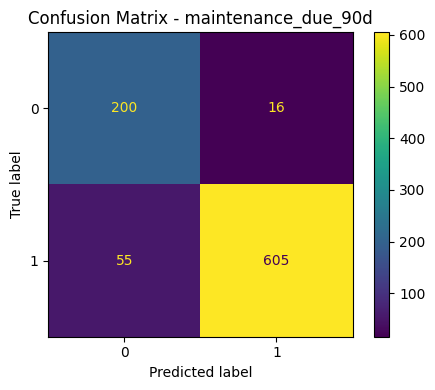

In [21]:
# Confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    y_pred_class,
    ax=ax
)

ax.set_title("Confusion Matrix - maintenance_due_90d")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "rf_confusion_matrix_maintenance_due_90d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
#Classifier feature importance

importance_class_df = pd.DataFrame({
    "feature": X_class.columns,
    "importance": best_rf_classifier.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_class_path = (
    OUTPUT_DIR / "random_forest_feature_importance_maintenance_due_90d.csv"
)

importance_class_df.to_csv(
    importance_class_path,
    index=False
)

importance_class_df

,feature,importance
2,days_since_maintenance,0.284278
3,hours_since_maintenance,0.251043
1,cumulative_op_hours,0.229139
5,humidity,0.061260
9,casing_temperature_c,0.050325
10,vibration_mm_s,0.023517
0,daily_op_hours,0.021937
4,daily_load_percent,0.017001
7,dust_index,0.016358
6,wind_gust_kph,0.016146


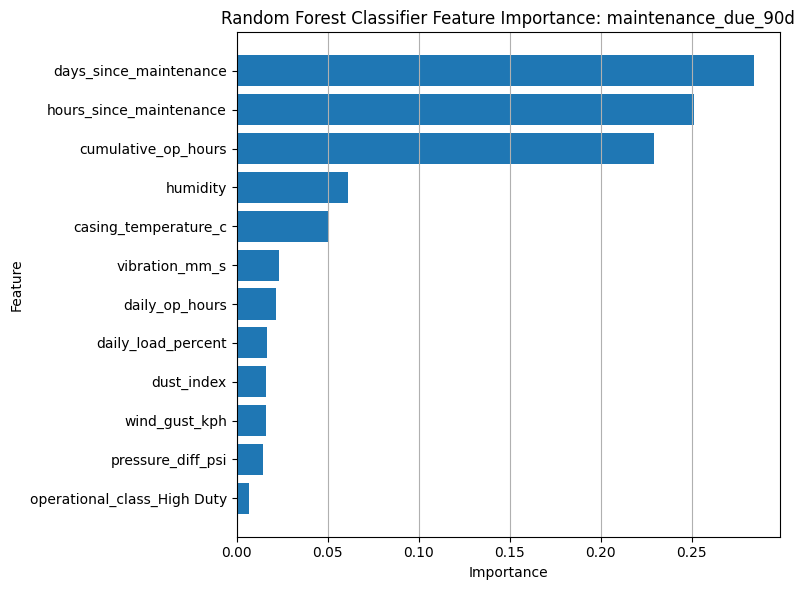

In [23]:
# Plotting classifier feature importance

top_n = 12

plot_df = importance_class_df.sort_values(
    by="importance",
    ascending=True
).tail(top_n)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    plot_df["feature"],
    plot_df["importance"]
)

ax.set_title("Random Forest Classifier Feature Importance: maintenance_due_90d")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(True, axis="x")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "rf_classifier_feature_importance_maintenance_due_90d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Saving classifier metrics and report

classifier_metrics = pd.DataFrame([{
    "model": "Random Forest Classifier",
    "features": "Option_A_Full_Model",
    "target": classifier_target,
    "best_cv_macro_recall": opt.best_score_,
    "accuracy": accuracy,
    "tp_recall": tp_recall,
    "tn_recall": tn_recall,
    "best_params": str(dict(opt.best_params_))
}])

classifier_metrics_path = (
    OUTPUT_DIR / "random_forest_classifier_metrics_maintenance_due_90d.csv"
)

classifier_metrics.to_csv(
    classifier_metrics_path,
    index=False
)

classification_report_df = pd.DataFrame(class_report_dict).transpose()

classification_report_path = (
    OUTPUT_DIR / "random_forest_classification_report_maintenance_due_90d.csv"
)

classification_report_df.to_csv(
    classification_report_path,
    index=True
)

classifier_metrics

,model,features,target,best_cv_macro_recall,accuracy,tp_recall,tn_recall,best_params
0,Random Forest Classifier,Option_A_Full_Model,maintenance_due_90d,0.936065,0.91895,0.916667,0.925926,"{'max_depth': 11, 'min_samples_leaf': 1, 'min_..."


In [25]:
# Saving classifier predictions

classifier_prediction_df = classifier_df.loc[X_test_class.index, [
    "date",
    "blower_id",
    "site_id",
    "operational_class",
    "maintenance_event",
    "maintenance_due_90d",
    "RUL_days",
    "degradation_index",
    "health_score"
]].copy()

classifier_prediction_df["actual_maintenance_due_90d"] = y_test_class.values
classifier_prediction_df["predicted_maintenance_due_90d"] = y_pred_class

classifier_prediction_path = (
    OUTPUT_DIR / "random_forest_classifier_predictions_maintenance_due_90d.csv"
)

classifier_prediction_df.to_csv(
    classifier_prediction_path,
    index=False
)

classifier_prediction_df.head()

,date,blower_id,site_id,operational_class,maintenance_event,maintenance_due_90d,RUL_days,degradation_index,health_score,actual_maintenance_due_90d,predicted_maintenance_due_90d
2963,2025-02-13,ZG250_B021,Site_03,High Duty,0,1,148.721767,0.222332,77.766840,1,1
1767,2025-11-04,ZG200_B011,Site_02,High Duty,0,0,172.546990,0.124234,87.576586,0,0
3632,2025-12-14,ZG250_B022,Site_03,Medium Duty,0,1,83.545916,0.599061,40.093888,1,1
2217,2025-01-28,ZG200_B013,Site_02,Low Duty,0,1,174.124152,0.134933,86.506746,1,0
2594,2025-02-09,ZG200_B014,Site_02,Low Duty,0,0,166.088371,0.185017,81.498262,0,0


In [26]:
# classifier results in dictionary

classifier_results["maintenance_due_90d"] = {
    "best_model": best_rf_classifier,
    "best_params": opt.best_params_,
    "best_cv_macro_recall": opt.best_score_,
    "accuracy": accuracy,
    "tp_recall": tp_recall,
    "tn_recall": tn_recall,
    "classification_report": class_report_dict,
    "feature_importance": importance_class_df,
    "model_path": classifier_model_path,
    "metrics_path": classifier_metrics_path,
    "classification_report_path": classification_report_path,
    "prediction_path": classifier_prediction_path
}

In [27]:
# Display classifier feature importance

print("\nFeature importance: maintenance_due_90d")
display(classifier_results["maintenance_due_90d"]["feature_importance"])


Feature importance: maintenance_due_90d


,feature,importance
2,days_since_maintenance,0.284278
3,hours_since_maintenance,0.251043
1,cumulative_op_hours,0.229139
5,humidity,0.061260
9,casing_temperature_c,0.050325
10,vibration_mm_s,0.023517
0,daily_op_hours,0.021937
4,daily_load_percent,0.017001
7,dust_index,0.016358
6,wind_gust_kph,0.016146


In [28]:
# Final summary

print("Random Forest modelling completed.")

print("\nRegression feature-set comparison:")
display(metrics_comparison)

print("\nSelected final regression model:")
print("Option A: Full Model")
print("Reason: This option includes cumulative operating hours, maintenance-history variables, condition-monitoring variables, environmental variables and operational class.")

print("\nClassifier summary:")
display(classifier_metrics)

print("\nSaved regression outputs:")
print(f"- RF three-option metrics comparison: {metrics_comparison_path}")
print(f"- Combined RF policy-ready test predictions: {combined_policy_path}")

print("\nSaved classifier outputs:")
print(f"- RF classifier model: {classifier_model_path}")
print(f"- RF classifier metrics: {classifier_metrics_path}")
print(f"- RF classification report: {classification_report_path}")
print(f"- RF classifier predictions: {classifier_prediction_path}")
print(f"- RF classifier feature importance: {importance_class_path}")

print("\nSaved folders:")
print(f"- Output directory: {OUTPUT_DIR}")
print(f"- Figure directory: {FIGURE_DIR}")

Random Forest modelling completed.

Regression feature-set comparison:


,option,model,target,number_of_features,train_start,train_end,test_start,test_end,mae_days,rmse_days,r2_score
0,Option_A_Full_Model,Random Forest Regressor,RUL_days,14,2025-01-01,2025-09-30,2025-10-01,2025-12-31,12.027344,16.824049,0.688255
2,Option_C_Condition_Only,Random Forest Regressor,RUL_days,8,2025-01-01,2025-09-30,2025-10-01,2025-12-31,27.517705,34.015926,-0.274391
1,Option_B_Reduced_With_Duty_Class,Random Forest Regressor,RUL_days,11,2025-01-01,2025-09-30,2025-10-01,2025-12-31,27.519249,34.015977,-0.274395



Selected final regression model:
Option A: Full Model
Reason: This option includes cumulative operating hours, maintenance-history variables, condition-monitoring variables, environmental variables and operational class.

Classifier summary:


,model,features,target,best_cv_macro_recall,accuracy,tp_recall,tn_recall,best_params
0,Random Forest Classifier,Option_A_Full_Model,maintenance_due_90d,0.936065,0.91895,0.916667,0.925926,"{'max_depth': 11, 'min_samples_leaf': 1, 'min_..."



Saved regression outputs:
- RF three-option metrics comparison: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\random_forest_three_option_metrics_comparison.csv
- Combined RF policy-ready test predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\random_forest_three_option_test_policy_predictions.csv

Saved classifier outputs:
- RF classifier model: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\random_forest_classifier_maintenance_due_90d.joblib
- RF classifier metrics: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\random_forest_classifier_metrics_maintenance_due_90d.csv
- RF classification report: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\RF_modeling\random_forest_classification_report_maintenance_due_90d.csv
- RF classifier predictions: C:\Users\USER\Documents\Shool projects\Predi